# PX4 Phase 1 Closed-Loop Dynamics PINN Training v17 Position State

This notebook retrains the v16 diagnostics baseline with scenario-local north/east position states:

- training/validation loss curves
- one-step RMSE/MAE tables and bar charts
- target-vs-predicted parity plots
- real contiguous 80-step rollout trajectory plots including north/east position

Model contract:

```text
x_t, setpoint_t, prev_setpoint_t, dsetpoint_t, dt_s -> dx_t
```


In [15]:
# Optional in Colab. Safe to skip locally if Drive is already mounted.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

DIAGNOSTIC_FIGURES = []


device: cuda
torch: 2.10.0+cu128


In [17]:
NOTEBOOK_REVISION = 'v17_position_state'
DATASET_GLOB_CANDIDATES = [
    '/content/drive/MyDrive/**/px4_phase1_closed_loop_yawrel_position_state_dataset_v8_*',
    '/content/drive/MyDrive/**/processed/px4_phase1_closed_loop_yawrel_position_state_dataset_v8_*',
    '/content/**/px4_phase1_closed_loop_yawrel_position_state_dataset_v8_*',
]
MANUAL_DATASET_DIR = ''  # Set this to a processed v8 dataset directory if auto-search misses it.

BATCH_SIZE = 2048
EPOCHS = 260
LR = 2.5e-3
WEIGHT_DECAY = 2e-4
GRAD_CLIP = 2.0
DROPOUT = 0.035
HIDDEN = 256
DEPTH = 4

# Soft physics terms. Keep these modest; the closed-loop PX4 plant is not a simple rigid-body-only model.
ALT_KIN_WEIGHT = 0.08
YAW_KIN_WEIGHT = 0.03
RATE_SMOOTH_WEIGHT = 0.01


In [18]:
import glob

def find_dataset_dir():
    if MANUAL_DATASET_DIR:
        p = Path(MANUAL_DATASET_DIR)
        if (p / 'train.csv').exists():
            return p
        raise FileNotFoundError(f'MANUAL_DATASET_DIR does not contain train.csv: {p}')
    matches = []
    for pat in DATASET_GLOB_CANDIDATES:
        matches.extend(Path(p) for p in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if (p / 'train.csv').exists()))
    if not matches:
        raise FileNotFoundError('No processed v8 position-state dataset found. Run px4_dataset_builder_v8_position_state first or set MANUAL_DATASET_DIR.')
    return matches[-1]

DATASET_DIR = find_dataset_dir()
print('DATASET_DIR:', DATASET_DIR)
for name in ['dataset_summary.csv', 'filter_report.csv', 'metadata.json']:
    p = DATASET_DIR / name
    print(name, p.exists())


DATASET_DIR: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_closed_loop_yawrel_position_state_dataset_v8_20260510_081623
dataset_summary.csv True
filter_report.csv True
metadata.json True


In [19]:
train_df = pd.read_csv(DATASET_DIR / 'train.csv')
val_df = pd.read_csv(DATASET_DIR / 'val.csv')
test_df = pd.read_csv(DATASET_DIR / 'test.csv')
summary_df = pd.read_csv(DATASET_DIR / 'dataset_summary.csv')
print('rows:', {k: len(v) for k, v in [('train', train_df), ('val', val_df), ('test', test_df)]})
display(summary_df)

STATE_COLS = [
    'local_north_m', 'local_east_m', 'relative_altitude_m',
    'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s',
    'roll_deg', 'pitch_deg', 'yaw_deg',
    'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s',
]
ACTION_COLS = [
    'ref_north_m', 'ref_east_m', 'ref_down_m',
    'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg',
]
TARGET_COLS = [f'dx_{c}' for c in STATE_COLS]
print('target columns:', TARGET_COLS)


rows: {'train': 23782, 'val': 4848, 'test': 5529}


,split,scenario,samples
0,test,C00_position_hold_25m,480
1,test,C01_altitude_step_25_28_25m,936
2,test,C02_altitude_step_25_22_25m,772
3,test,C03_north_position_step_pm2m,419
4,test,C04_east_position_step_pm2m,407
5,test,C05_yaw_position_hold_pm20deg,640
6,test,C06_velocity_north_doublet_0p5mps,271
7,test,C07_velocity_east_doublet_0p5mps,160
8,test,C08_vertical_velocity_doublet_0p25mps,198
9,test,C09_mixed_position_sequence,1246


target columns: ['dx_local_north_m', 'dx_local_east_m', 'dx_relative_altitude_m', 'dx_vel_north_m_s', 'dx_vel_east_m_s', 'dx_vel_down_m_s', 'dx_roll_deg', 'dx_pitch_deg', 'dx_yaw_deg', 'dx_roll_rate_rad_s', 'dx_pitch_rate_rad_s', 'dx_yaw_rate_rad_s']


In [20]:
def angle_sin_deg(s):
    return np.sin(np.deg2rad(pd.to_numeric(s, errors='coerce').to_numpy(dtype=np.float32)))

def angle_cos_deg(s):
    return np.cos(np.deg2rad(pd.to_numeric(s, errors='coerce').to_numpy(dtype=np.float32)))

def make_features(df):
    parts = []
    names = []

    # Current state. Use sin/cos for yaw to avoid discontinuity at +/-180 deg.
    for col in STATE_COLS:
        src = f'x_{col}'
        if col == 'yaw_deg':
            parts.append(angle_sin_deg(df[src])[:, None]); names.append('x_yaw_sin')
            parts.append(angle_cos_deg(df[src])[:, None]); names.append('x_yaw_cos')
        else:
            parts.append(pd.to_numeric(df[src], errors='coerce').to_numpy(dtype=np.float32)[:, None]); names.append(src)

    # Current, previous, and delta setpoints. Encode yaw references cyclically.
    for prefix in ['u_', 'prev_u_', 'du_']:
        for col in ACTION_COLS:
            src = prefix + col
            if col == 'ref_yaw_deg' and prefix != 'du_':
                parts.append(angle_sin_deg(df[src])[:, None]); names.append(src + '_sin')
                parts.append(angle_cos_deg(df[src])[:, None]); names.append(src + '_cos')
            else:
                values = pd.to_numeric(df[src], errors='coerce').to_numpy(dtype=np.float32)
                if col == 'ref_yaw_deg':
                    values = ((values + 180.0) % 360.0) - 180.0
                parts.append(values[:, None]); names.append(src)

    parts.append(pd.to_numeric(df['dt_s'], errors='coerce').to_numpy(dtype=np.float32)[:, None]); names.append('dt_s')
    X = np.concatenate(parts, axis=1).astype(np.float32)
    return X, names

def make_targets(df):
    Y = np.stack([pd.to_numeric(df[c], errors='coerce').to_numpy(dtype=np.float32) for c in TARGET_COLS], axis=1)
    return Y.astype(np.float32)

X_train, FEATURE_COLS = make_features(train_df)
X_val, _ = make_features(val_df)
X_test, _ = make_features(test_df)
Y_train = make_targets(train_df)
Y_val = make_targets(val_df)
Y_test = make_targets(test_df)

print('feature dim:', X_train.shape[1])
print('target dim:', Y_train.shape[1])
print('bad train finite:', np.isfinite(X_train).all(), np.isfinite(Y_train).all())


feature dim: 40
target dim: 12
bad train finite: True True


In [21]:
class Standardizer:
    def __init__(self, x, eps=1e-6):
        self.mean = torch.tensor(np.nanmean(x, axis=0), dtype=torch.float32)
        self.std = torch.tensor(np.nanstd(x, axis=0), dtype=torch.float32).clamp_min(eps)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)
    def to_dict(self):
        return {'mean': self.mean.cpu().numpy().tolist(), 'std': self.std.cpu().numpy().tolist()}

x_scaler = Standardizer(X_train)
y_scaler = Standardizer(Y_train)

def loader_for(X, Y, shuffle):
    Xz = x_scaler.encode(X)
    Yz = y_scaler.encode(Y)
    ds = TensorDataset(Xz, Yz)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False, num_workers=0)

train_loader = loader_for(X_train, Y_train, True)
val_loader = loader_for(X_val, Y_val, False)
test_loader = loader_for(X_test, Y_test, False)


In [22]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

model = ResidualMLP(X_train.shape[1], Y_train.shape[1], HIDDEN, DEPTH, DROPOUT).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR * 0.06)

state_index = {name: i for i, name in enumerate(STATE_COLS)}
target_index = {name: i for i, name in enumerate(TARGET_COLS)}
feature_index = {name: i for i, name in enumerate(FEATURE_COLS)}


In [23]:
def denorm_x(xz):
    return x_scaler.decode(xz)

def denorm_y(yz):
    return y_scaler.decode(yz)

def physics_losses(xz, pred_yz):
    x = denorm_x(xz)
    dy = denorm_y(pred_yz)
    dt = x[:, feature_index['dt_s']].clamp_min(1e-3)

    # relative_altitude_dot ~= -vel_down in NED coordinates. Use midpoint velocity.
    dx_h = dy[:, target_index['dx_relative_altitude_m']]
    vdown = x[:, feature_index['x_vel_down_m_s']]
    dvdown = dy[:, target_index['dx_vel_down_m_s']]
    vdown_mid = vdown + 0.5 * dvdown
    alt_res = dx_h / dt + vdown_mid
    alt_loss = torch.mean(alt_res ** 2)

    # small-angle yaw kinematic prior; deliberately weak for multicopter closed-loop data.
    dx_yaw_rad = torch.deg2rad(dy[:, target_index['dx_yaw_deg']])
    yaw_rate = x[:, feature_index['x_yaw_rate_rad_s']]
    yaw_res = dx_yaw_rad / dt - yaw_rate
    yaw_loss = torch.mean(yaw_res ** 2)

    rate_cols = ['dx_roll_rate_rad_s', 'dx_pitch_rate_rad_s', 'dx_yaw_rate_rad_s']
    rate_loss = torch.stack([dy[:, target_index[c]].pow(2).mean() for c in rate_cols]).mean()
    return alt_loss, yaw_loss, rate_loss

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals = {'loss': 0.0, 'data': 0.0, 'alt': 0.0, 'yaw': 0.0, 'rate': 0.0, 'n': 0}
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train_mode:
            opt.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train_mode):
            pred = model(xb)
            data_loss = torch.mean((pred - yb) ** 2)
            alt_loss, yaw_loss, rate_loss = physics_losses(xb, pred)
            loss = data_loss + ALT_KIN_WEIGHT * alt_loss + YAW_KIN_WEIGHT * yaw_loss + RATE_SMOOTH_WEIGHT * rate_loss
            if train_mode:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
        bs = xb.shape[0]
        totals['loss'] += float(loss.detach().cpu()) * bs
        totals['data'] += float(data_loss.detach().cpu()) * bs
        totals['alt'] += float(alt_loss.detach().cpu()) * bs
        totals['yaw'] += float(yaw_loss.detach().cpu()) * bs
        totals['rate'] += float(rate_loss.detach().cpu()) * bs
        totals['n'] += bs
    return {k: v / max(totals['n'], 1) for k, v in totals.items() if k != 'n'}


In [24]:
best_val = float('inf')
best_state = None
history = []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step()
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}, 'lr': scheduler.get_last_lr()[0]}
    history.append(row)
    if va['loss'] < best_val:
        best_val = va['loss']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch == 1 or epoch % 20 == 0:
        print(f"epoch {epoch:04d} train={tr['loss']:.5f} val={va['loss']:.5f} data={va['data']:.5f} alt={va['alt']:.5f} yaw={va['yaw']:.5f}")

if best_state is not None:
    model.load_state_dict(best_state)
print('best val:', best_val, 'elapsed min:', round((time.time() - t0) / 60, 2))
history_df = pd.DataFrame(history)
display(history_df.tail())


epoch 0001 train=0.69511 val=0.46019 data=0.45983 alt=0.00419 yaw=0.00063
epoch 0020 train=0.07625 val=0.08067 data=0.08047 alt=0.00233 yaw=0.00021
epoch 0040 train=0.06808 val=0.06932 data=0.06911 alt=0.00250 yaw=0.00018
epoch 0060 train=0.06063 val=0.06777 data=0.06757 alt=0.00242 yaw=0.00020
epoch 0080 train=0.05569 val=0.06399 data=0.06377 alt=0.00261 yaw=0.00018
epoch 0100 train=0.05181 val=0.06134 data=0.06113 alt=0.00262 yaw=0.00019
epoch 0120 train=0.05066 val=0.05998 data=0.05979 alt=0.00235 yaw=0.00019
epoch 0140 train=0.04913 val=0.05965 data=0.05944 alt=0.00245 yaw=0.00019
epoch 0160 train=0.04760 val=0.05943 data=0.05922 alt=0.00250 yaw=0.00020
epoch 0180 train=0.04485 val=0.05808 data=0.05787 alt=0.00256 yaw=0.00019
epoch 0200 train=0.04339 val=0.05671 data=0.05649 alt=0.00257 yaw=0.00019
epoch 0220 train=0.04475 val=0.05689 data=0.05668 alt=0.00254 yaw=0.00020
epoch 0240 train=0.04292 val=0.05651 data=0.05630 alt=0.00259 yaw=0.00020
epoch 0260 train=0.04290 val=0.05617 d

,epoch,train_loss,train_data,train_alt,train_yaw,train_rate,val_loss,val_data,val_alt,val_yaw,val_rate,lr
255,256,0.041674,0.041328,0.004276,0.000115,0.000130,0.056364,0.056152,0.002556,0.000199,0.000177,0.000151
256,257,0.042206,0.041864,0.004214,0.000118,0.000131,0.056408,0.056197,0.002542,0.000194,0.000176,0.000151
257,258,0.042300,0.041953,0.004274,0.000116,0.000131,0.056388,0.056177,0.002547,0.000195,0.000178,0.000150
258,259,0.042270,0.041928,0.004215,0.000115,0.000130,0.056513,0.056300,0.002562,0.000197,0.000175,0.000150
259,260,0.042902,0.042554,0.004295,0.000116,0.000129,0.056171,0.055959,0.002554,0.000199,0.000177,0.000150


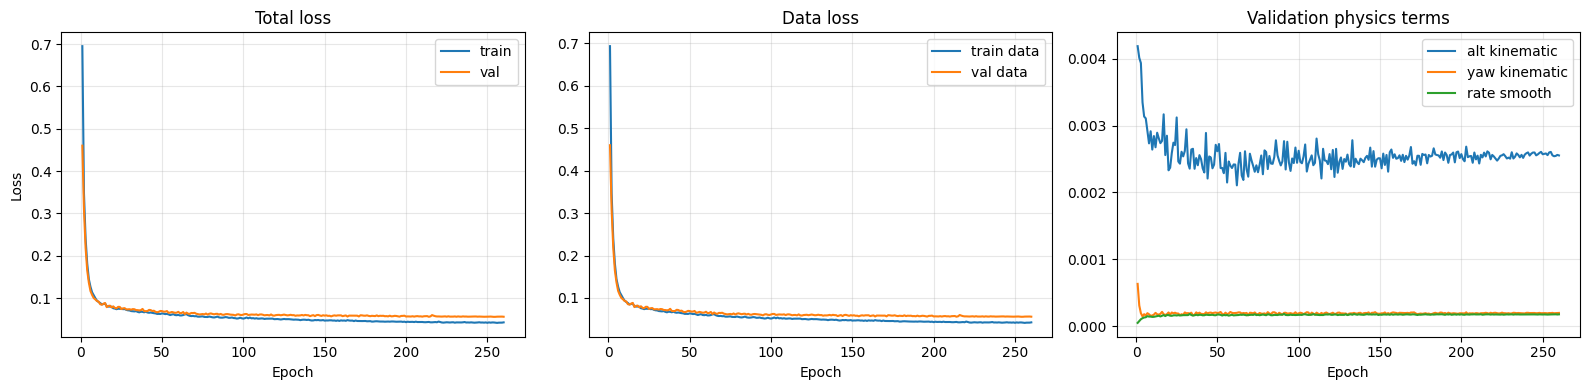

In [25]:
# Visual diagnostics: training curves
fig_loss, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[0].set_title('Total loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_data'], label='train data')
axes[1].plot(history_df['epoch'], history_df['val_data'], label='val data')
axes[1].set_title('Data loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_alt'], label='alt kinematic')
axes[2].plot(history_df['epoch'], history_df['val_yaw'], label='yaw kinematic')
axes[2].plot(history_df['epoch'], history_df['val_rate'], label='rate smooth')
axes[2].set_title('Validation physics terms')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
fig_loss.tight_layout()
DIAGNOSTIC_FIGURES.append(('loss_curves', fig_loss))
plt.show()


In [26]:
@torch.no_grad()
def predict_denorm(X):
    model.eval()
    Xz = x_scaler.encode(X).to(device)
    preds = []
    for i in range(0, len(Xz), 8192):
        yz = model(Xz[i:i+8192])
        preds.append(denorm_y(yz).cpu().numpy())
    return np.concatenate(preds, axis=0)

def metric_table(name, X, Y):
    P = predict_denorm(X)
    rows = []
    for i, col in enumerate(TARGET_COLS):
        err = P[:, i] - Y[:, i]
        rows.append({
            'split': name,
            'target': col.replace('dx_', ''),
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(Y[:, i])),
        })
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    metric_table('train', X_train, Y_train),
    metric_table('val', X_val, Y_val),
    metric_table('test', X_test, Y_test),
], ignore_index=True)
display(metrics_df)


,split,target,rmse,mae,std_true
0,train,local_north_m,0.000240,0.000127,0.006194
1,train,local_east_m,0.000348,0.000183,0.008988
2,train,relative_altitude_m,0.002189,0.001253,0.010789
3,train,vel_north_m_s,0.003627,0.001866,0.013895
4,train,vel_east_m_s,0.004211,0.002331,0.017091
5,train,vel_down_m_s,0.003544,0.001368,0.011886
6,train,roll_deg,0.015488,0.006226,0.143527
7,train,pitch_deg,0.017196,0.007524,0.167920
8,train,yaw_deg,0.012843,0.006040,0.113534
9,train,roll_rate_rad_s,0.003035,0.001317,0.013940


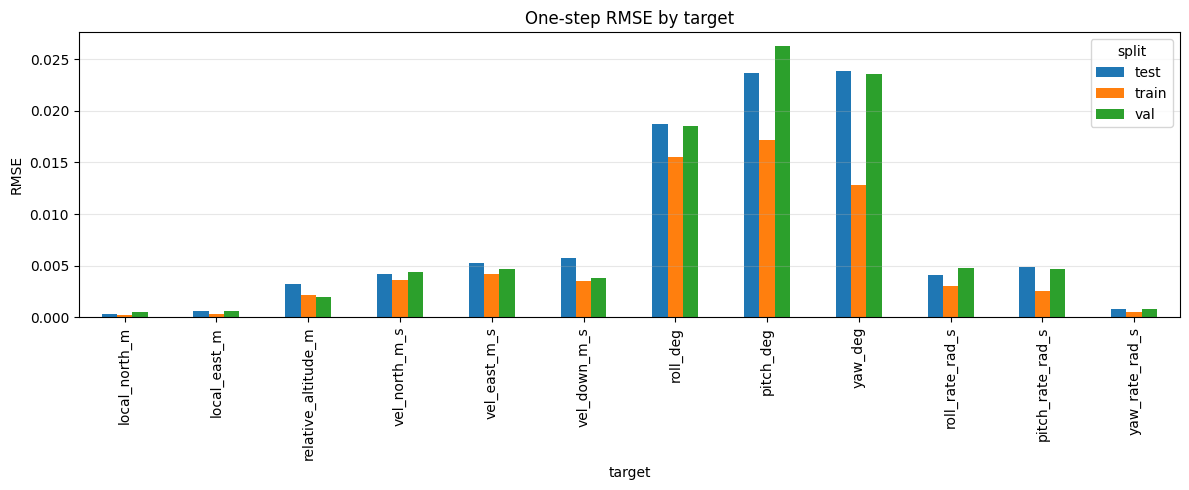

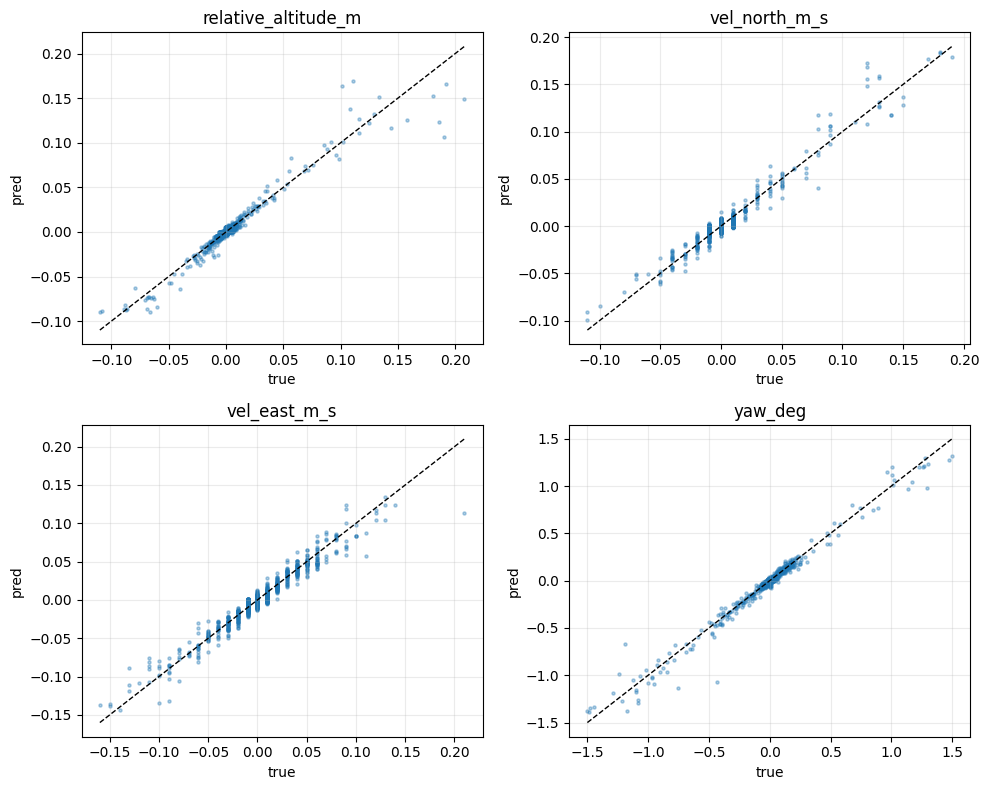

In [27]:
# Visual diagnostics: one-step metric bars and parity plots
metric_pivot = metrics_df.pivot(index='target', columns='split', values='rmse').loc[[c.replace('dx_', '') for c in TARGET_COLS]]
fig_rmse, ax = plt.subplots(figsize=(12, 5))
metric_pivot.plot(kind='bar', ax=ax)
ax.set_title('One-step RMSE by target')
ax.set_ylabel('RMSE')
ax.grid(True, axis='y', alpha=0.3)
fig_rmse.tight_layout()
DIAGNOSTIC_FIGURES.append(('one_step_rmse', fig_rmse))
plt.show()

# Parity plots for targets that matter most for the next MPC step.
P_test = predict_denorm(X_test)
parity_targets = ['dx_relative_altitude_m', 'dx_vel_north_m_s', 'dx_vel_east_m_s', 'dx_yaw_deg']
fig_parity, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, target in zip(axes.ravel(), parity_targets):
    i = TARGET_COLS.index(target)
    y_true = Y_test[:, i]
    y_pred = P_test[:, i]
    n = min(len(y_true), 4000)
    idx = np.linspace(0, len(y_true) - 1, n).astype(int)
    ax.scatter(y_true[idx], y_pred[idx], s=5, alpha=0.35)
    lo = float(min(y_true[idx].min(), y_pred[idx].min()))
    hi = float(max(y_true[idx].max(), y_pred[idx].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(target.replace('dx_', ''))
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
    ax.grid(True, alpha=0.25)
fig_parity.tight_layout()
DIAGNOSTIC_FIGURES.append(('one_step_parity', fig_parity))
plt.show()


,scenario,ref_label,block_id,horizon,north_rmse_m,east_rmse_m,xy_rmse_m,alt_rmse_m,vn_rmse_m_s,ve_rmse_m_s,yaw_rmse_deg
0,C00_position_hold_25m,hold_25m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.014242,0.009450,0.017092,0.024019,0.013336,0.005475,0.054747
1,C00_position_hold_25m,hold_25m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.008314,0.038743,0.039625,0.012994,0.014407,0.026041,0.120724
2,C01_altitude_step_25_28_25m,return_25m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.015326,0.018758,0.024223,0.131727,0.018568,0.019331,0.047252
3,C01_altitude_step_25_28_25m,return_25m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.010535,0.009725,0.014337,0.041904,0.013026,0.018754,0.030110
4,C03_north_position_step_pm2m,recovery,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.015377,0.002805,0.015630,0.020162,0.008379,0.008845,0.025575
5,C05_yaw_position_hold_pm20deg,yaw_zero_1,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.008315,0.011986,0.014588,0.037163,0.018199,0.019307,0.188897
6,C09_mixed_position_sequence,recovery,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.007448,0.076362,0.076725,0.016060,0.010386,0.039622,0.158348
7,C01_altitude_step_25_28_25m,pre_hold_25m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.009334,0.017617,0.019938,0.039877,0.009161,0.021757,0.135839
8,C02_altitude_step_25_22_25m,return_25m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.017670,0.034804,0.039033,0.122477,0.014407,0.022038,0.113238
9,C04_east_position_step_pm2m,east_plus_2m,px4_phase1_standard_vtol_closed_loop_yawrel_da...,80,0.027590,0.007450,0.028579,0.033835,0.014686,0.022387,0.216882


rollout means:


,horizon,north_rmse_m,east_rmse_m,xy_rmse_m,alt_rmse_m,vn_rmse_m_s,ve_rmse_m_s,yaw_rmse_deg
mean,80.0,0.01624,0.020091,0.0275,0.047729,0.015259,0.020685,0.117685


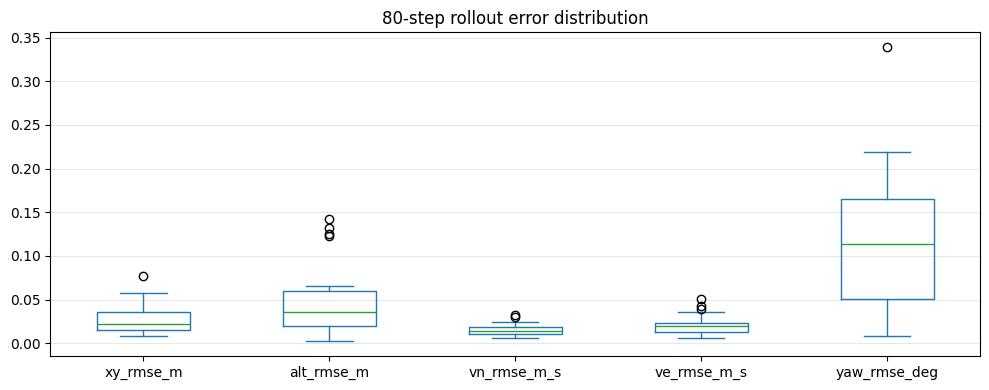

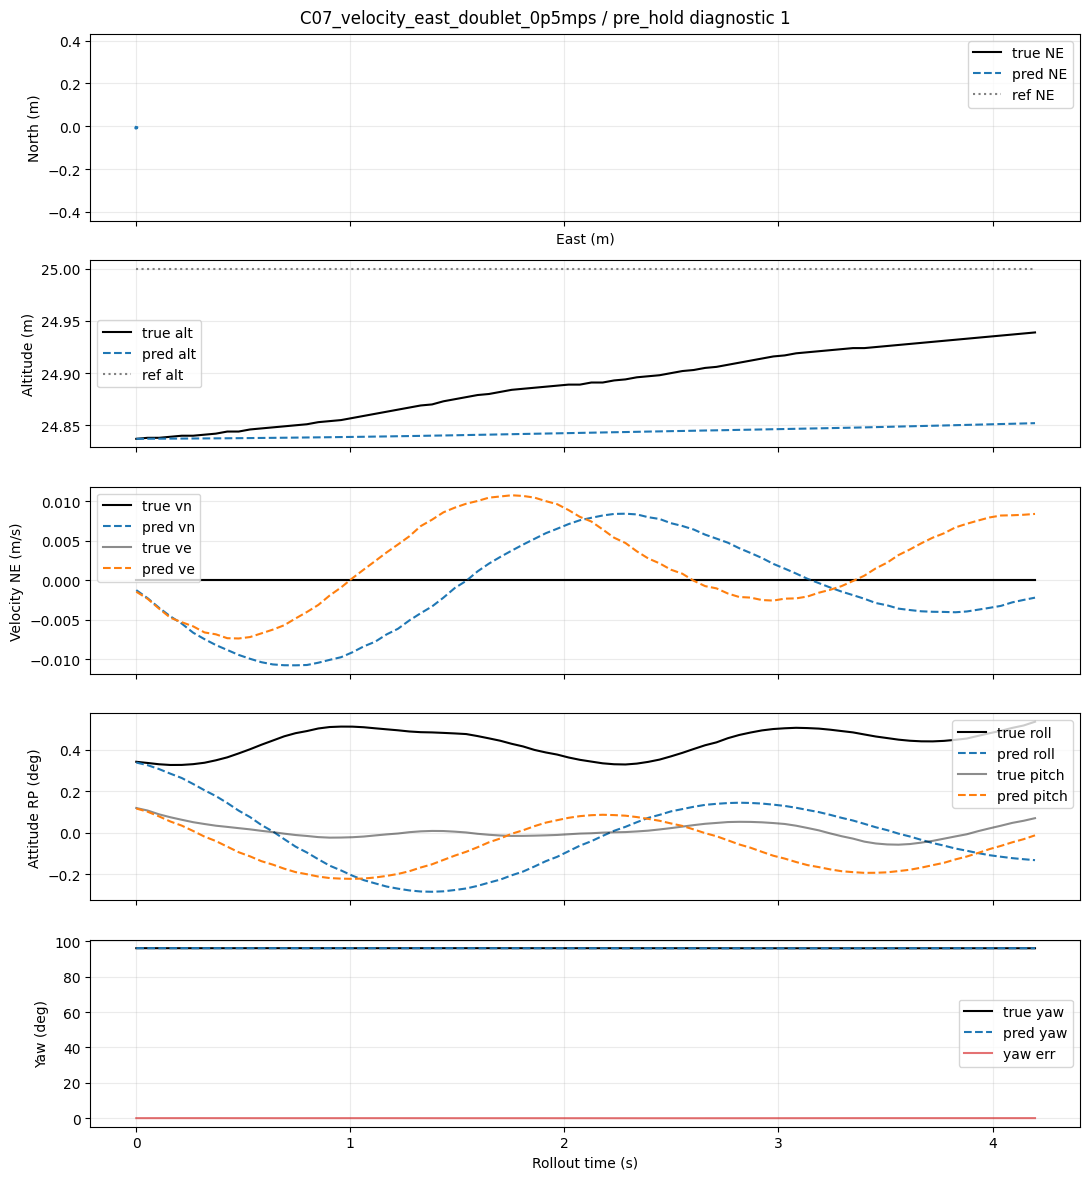

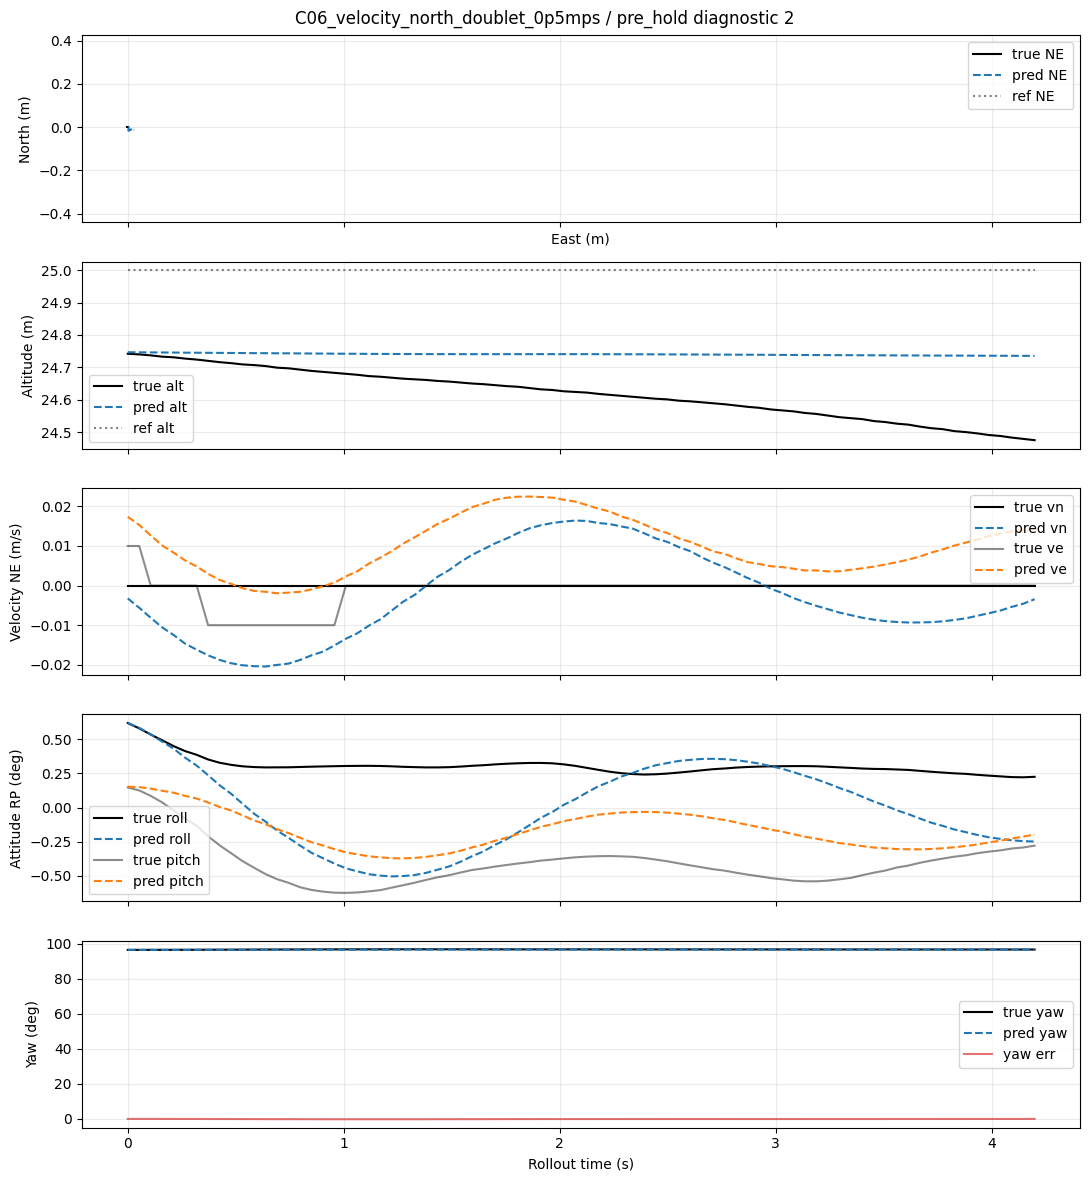

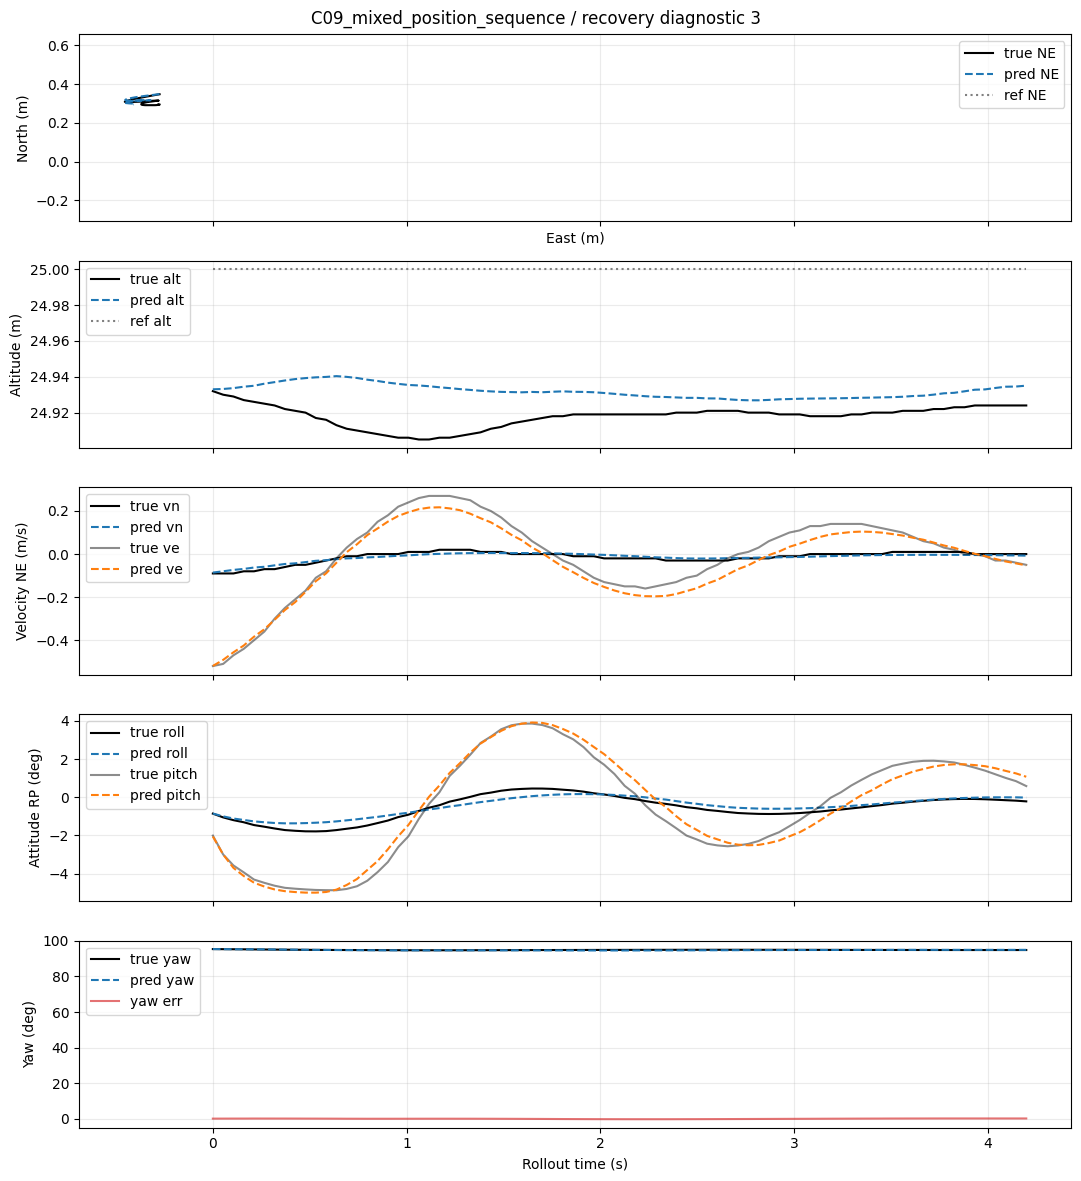

In [28]:
def rollout_segments(df, max_segments=24, horizon=80):
    # v8 keeps block_id-contiguous test windows, so rollout can evaluate real
    # consecutive trajectories instead of stitched random rows.
    out = []
    if 'block_id' in df.columns:
        group_cols = ['source_run', 'scenario', 'block_id'] if 'source_run' in df.columns else ['scenario', 'block_id']
    else:
        group_cols = ['source_run', 'scenario'] if 'source_run' in df.columns else ['scenario']
    ordered = df.sort_values([c for c in [*group_cols, 'sample_index'] if c in df.columns])
    for _, g in ordered.groupby(group_cols):
        g = g.sort_values('sample_index')
        sample_idx = g['sample_index'].to_numpy()
        start = 0
        for j in range(1, len(g) + 1):
            end_block = (j == len(g)) or (sample_idx[j] != sample_idx[j - 1] + 1)
            if end_block:
                block = g.iloc[start:j]
                if len(block) >= horizon:
                    out.append(block.iloc[:horizon].copy())
                    if len(out) >= max_segments:
                        return out
                start = j
    return out

@torch.no_grad()
def rollout_predict(segment):
    cur = segment.iloc[0].copy()
    pred_states = []
    true_states = []
    for k in range(len(segment)):
        row = segment.iloc[k].copy()
        for c in STATE_COLS:
            row[f'x_{c}'] = cur[f'x_{c}']
        Xk, _ = make_features(pd.DataFrame([row]))
        dx = predict_denorm(Xk)[0]
        next_state = {}
        for i, c in enumerate(STATE_COLS):
            value = float(cur[f'x_{c}'] + dx[i])
            if c == 'yaw_deg':
                value = ((value + 180.0) % 360.0) - 180.0
            next_state[f'x_{c}'] = value
        pred_states.append([next_state[f'x_{c}'] for c in STATE_COLS])
        true_states.append([segment.iloc[k][f'x_next_{c}'] for c in STATE_COLS])
        cur = pd.Series(next_state)
    return np.asarray(pred_states), np.asarray(true_states, dtype=np.float32)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def yaw_rmse_deg(pred, true):
    err = ((np.asarray(pred) - np.asarray(true) + 180.0) % 360.0) - 180.0
    return float(np.sqrt(np.mean(err ** 2)))

def rollout_error(segment):
    P, T = rollout_predict(segment)
    ix = state_index
    north_rmse = rmse(P[:, ix['local_north_m']], T[:, ix['local_north_m']])
    east_rmse = rmse(P[:, ix['local_east_m']], T[:, ix['local_east_m']])
    return {
        'scenario': str(segment.iloc[0]['scenario']),
        'ref_label': str(segment.iloc[0]['ref_label']),
        'block_id': str(segment.iloc[0].get('block_id', '')),
        'horizon': len(segment),
        'north_rmse_m': north_rmse,
        'east_rmse_m': east_rmse,
        'xy_rmse_m': float(np.sqrt(north_rmse ** 2 + east_rmse ** 2)),
        'alt_rmse_m': rmse(P[:, ix['relative_altitude_m']], T[:, ix['relative_altitude_m']]),
        'vn_rmse_m_s': rmse(P[:, ix['vel_north_m_s']], T[:, ix['vel_north_m_s']]),
        've_rmse_m_s': rmse(P[:, ix['vel_east_m_s']], T[:, ix['vel_east_m_s']]),
        'yaw_rmse_deg': yaw_rmse_deg(P[:, ix['yaw_deg']], T[:, ix['yaw_deg']]),
    }

def plot_rollout_segment(segment, title_suffix=''):
    P, T = rollout_predict(segment)
    ix = state_index
    t = np.arange(len(segment)) * float(segment['dt_s'].median())
    fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)
    fig.suptitle(f"{segment.iloc[0]['scenario']} / {segment.iloc[0]['ref_label']} {title_suffix}")

    axes[0].plot(T[:, ix['local_east_m']], T[:, ix['local_north_m']], 'k-', label='true NE')
    axes[0].plot(P[:, ix['local_east_m']], P[:, ix['local_north_m']], 'tab:blue', ls='--', label='pred NE')
    if {'u_ref_east_m', 'u_ref_north_m'}.issubset(segment.columns):
        axes[0].plot(segment['u_ref_east_m'].to_numpy(), segment['u_ref_north_m'].to_numpy(), '0.5', ls=':', label='ref NE')
    axes[0].set_ylabel('North (m)')
    axes[0].set_xlabel('East (m)')
    axes[0].axis('equal')

    axes[1].plot(t, T[:, ix['relative_altitude_m']], 'k-', label='true alt')
    axes[1].plot(t, P[:, ix['relative_altitude_m']], 'tab:blue', ls='--', label='pred alt')
    if 'u_ref_down_m' in segment:
        axes[1].plot(t, -segment['u_ref_down_m'].to_numpy(), '0.5', ls=':', label='ref alt')
    axes[1].set_ylabel('Altitude (m)')

    axes[2].plot(t, T[:, ix['vel_north_m_s']], 'k-', label='true vn')
    axes[2].plot(t, P[:, ix['vel_north_m_s']], 'tab:blue', ls='--', label='pred vn')
    axes[2].plot(t, T[:, ix['vel_east_m_s']], 'k-', alpha=0.45, label='true ve')
    axes[2].plot(t, P[:, ix['vel_east_m_s']], 'tab:orange', ls='--', label='pred ve')
    axes[2].set_ylabel('Velocity NE (m/s)')

    axes[3].plot(t, T[:, ix['roll_deg']], 'k-', label='true roll')
    axes[3].plot(t, P[:, ix['roll_deg']], 'tab:blue', ls='--', label='pred roll')
    axes[3].plot(t, T[:, ix['pitch_deg']], 'k-', alpha=0.45, label='true pitch')
    axes[3].plot(t, P[:, ix['pitch_deg']], 'tab:orange', ls='--', label='pred pitch')
    axes[3].set_ylabel('Attitude RP (deg)')

    yaw_err = ((P[:, ix['yaw_deg']] - T[:, ix['yaw_deg']] + 180.0) % 360.0) - 180.0
    axes[4].plot(t, T[:, ix['yaw_deg']], 'k-', label='true yaw')
    axes[4].plot(t, P[:, ix['yaw_deg']], 'tab:blue', ls='--', label='pred yaw')
    axes[4].plot(t, yaw_err, 'tab:red', alpha=0.65, label='yaw err')
    axes[4].set_ylabel('Yaw (deg)')
    axes[4].set_xlabel('Rollout time (s)')

    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')
    fig.tight_layout()
    return fig

rollout_segs = rollout_segments(test_df, max_segments=24, horizon=80)
roll_rows = [rollout_error(seg) for seg in rollout_segs]
rollout_df = pd.DataFrame(roll_rows)
display(rollout_df)
print('rollout means:')
display(rollout_df.mean(numeric_only=True).to_frame('mean').T if len(rollout_df) else rollout_df)

if len(rollout_df):
    fig_roll_bar, ax = plt.subplots(figsize=(10, 4))
    rollout_df[['xy_rmse_m', 'alt_rmse_m', 'vn_rmse_m_s', 've_rmse_m_s', 'yaw_rmse_deg']].plot(kind='box', ax=ax)
    ax.set_title('80-step rollout error distribution')
    ax.grid(True, axis='y', alpha=0.3)
    fig_roll_bar.tight_layout()
    DIAGNOSTIC_FIGURES.append(('rollout_error_box', fig_roll_bar))
    plt.show()

    selected_indices = []
    selected_indices.append(int(rollout_df['xy_rmse_m'].idxmin()))
    selected_indices.append(int((rollout_df['xy_rmse_m'] - rollout_df['xy_rmse_m'].median()).abs().idxmin()))
    selected_indices.append(int(rollout_df['xy_rmse_m'].idxmax()))
    for rank, idx in enumerate(dict.fromkeys(selected_indices).keys(), start=1):
        fig = plot_rollout_segment(rollout_segs[idx], title_suffix=f"diagnostic {rank}")
        DIAGNOSTIC_FIGURES.append((f'rollout_trace_{rank}', fig))
        plt.show()


In [29]:
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_position_state_training_v17')
else:
    SAVE_ROOT = Path('/content/px4_phase1_closed_loop_position_state_training_v17')
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
SAVE_DIR = SAVE_ROOT / RUN_STAMP
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ckpt = {
    'revision': NOTEBOOK_REVISION,
    'dataset_dir': str(DATASET_DIR),
    'state_cols': STATE_COLS,
    'action_cols': ACTION_COLS,
    'target_cols': TARGET_COLS,
    'feature_cols': FEATURE_COLS,
    'model_config': {'hidden': HIDDEN, 'depth': DEPTH, 'dropout': DROPOUT},
    'model_state_dict': model.cpu().state_dict(),
    'x_scaler': x_scaler.to_dict(),
    'y_scaler': y_scaler.to_dict(),
    'history': history_df.to_dict(orient='records'),
}
torch.save(ckpt, SAVE_DIR / 'px4_closed_loop_position_state_dynamics_pinn_v17.pt')
history_df.to_csv(SAVE_DIR / 'training_history.csv', index=False)
metrics_df.to_csv(SAVE_DIR / 'one_step_metrics.csv', index=False)
rollout_df.to_csv(SAVE_DIR / 'rollout_metrics.csv', index=False)
for name, fig in DIAGNOSTIC_FIGURES:
    fig.savefig(SAVE_DIR / f'{name}.png', dpi=160, bbox_inches='tight')
print('saved:', SAVE_DIR)
print('saved figures:', [name for name, _ in DIAGNOSTIC_FIGURES])


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_position_state_training_v17/20260509_232358
saved figures: ['loss_curves', 'one_step_rmse', 'one_step_parity', 'rollout_error_box', 'rollout_trace_1', 'rollout_trace_2', 'rollout_trace_3']
